In [1]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:85% !important;}
div.cell.code_cell.rendered{width:100%;}
div.input_prompt{padding:0px;}
div.CodeMirror {font-family:Consolas; font-size:16pt;}
div.output {font-size:12pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:12pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:12pt;padding:5px;}
table.dataframe{font-size:12px;}
</style>
"""))

<font size="5" color="red"><b>ch2. 군집분석</b></font>
# 1절. 군집모델(클러스터링)
- 클러스터(cluster) : 독립변수의 특성이 유사한 데이터의 그룹
- 클러스터링(clustering) : 주어진 데이터를 여러 개의 클러스터로 구분하는 것
1) 중심 기반 클러스터링(K-Means) : https://commons.wikimedia.org/wiki/File:KMeans-Gaussiandata.svg
<img src="https://upload.wikimedia.org/wikipedia/commons/e/e5/KMeans-Gaussian-data.svg"
style="display: block; margin-left: 0; width: 20%;">
2) 연결기반 클러스터링(DBSCAN) : https://commons.wikimedia.org/wiki/File:DBSCAN-densitydata.svg
<img src="https://upload.wikimedia.org/wikipedia/commons/0/05/DBSCAN-density-data.svg"
width="300"
style="display: block; margin-left: 0; width: 20%;">
3) 밀도기반 클러스터링(DBSCAN의 변형으로 OPTICS) :
https://commons.wikimedia.org/wiki/File:OPTICS-Gaussian-data.svg
<img src="https://upload.wikimedia.org/wikipedia/commons/8/8a/OPTICS-Gaussian-data.svg"
width="300"
style="display: block; margin-left: 0; width: 20%;">

# 2절. K-Means 클러스터링
- 가장 단순하고 빠른 클러스터링 알고리즘의 하나
- 목적함수 값이 최소화될 때까지 클러스터의 중심(centroid) 𝜇k와 각 데이터가 소속될 클러스터를 반복해서 찾는 것
- K-Means 클러스터링의 세부 알고리즘
1. 임의의 중심값 μk를 고릅니다.(보통 데이터 샘플 중의 하나를 선택합니다.)
2. 중심에서 각 샘플 데이터까지의 거리를 계산합니다.
3. 각 데이터 샘플에서 가장 가까운 중심을 선택하여 클러스터 갱신합니다.
4. 다시 만들어진 클러스터에 대해 중심을 다시 계산하고 1~4를 반복합니다

In [3]:
import matplotlib.pyplot as plt
plt.rc('font',family='Malgun Gothic')
plt.rcParams['font.family']='Malgun Gothic'  #한글 꺠짐 방지
plt.rcParams['axes.unicode_minus'] =False    # 축의 깨짐방지
plt.rcParams['figure.figsize'] = (10,4) # 모든 시각화 사이즈

In [4]:
# 분류를 위한 가상 데이터셋 생성
from sklearn.datasets import make_classification
X,y = make_classification(n_samples=20, #데이터 갯수(기본값100) : 20행
                          n_features=2, #독립변수 갯수(기본값20)
                          n_informative=2, #독립변수 중 종속변수에 영향을 주는 독립변수갯수(기본값2)
                          n_redundant =0,  #종속변수 영향을 안 미치는 독립변수 갯수(기본값2)
                          n_classes=2,     # 종속변수의 클래스 수(0, 2) 
                          n_clusters_per_class=1, #각 클래스 당 군의 갯수(서브그룹이 없음)
                          random_state=123
                         )

X.shape,y.shape 

((20, 2), (20,))

In [5]:
#5:5로 분류 되었는지 확인
import numpy as np
value, cnt = np.unique(y, return_counts=True)
{v:c for v,c in zip(value, cnt)}

{0: 10, 1: 10}

In [6]:
np.c_[X,y]
np.column_stack([X,y])[:3]     # 두개 똑같음

array([[ 1.03859554,  2.51175389,  0.        ],
       [ 1.00271366,  1.93521549,  0.        ],
       [-1.6881048 ,  0.02599427,  1.        ]])

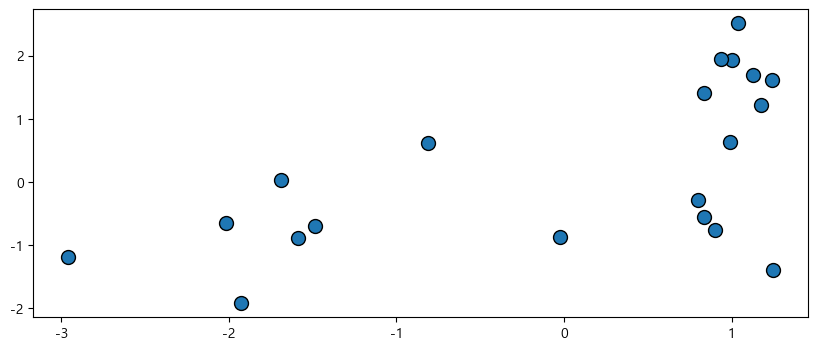

In [9]:
plt.scatter(X[:,0], X[:,1], c=y, s=100, edgecolors='k')
plt.show()

In [10]:
from sklearn.cluster import KMeans
model = KMeans(n_clusters=2, # class 갯수 ( 군의 갯수)
        init ='k-means++', # 임의의 초기중심점이 서로 멀리 떨어지도록 똑똑하게 초기화/'random'     
        max_iter=300, # 각 실행에서 최대 300번 중심점 이동(중심점이 이동되지 않으면 300까지 안함)
        n_init='auto'
              )
model.fit(X)

KMeans(n_clusters=2, n_init='auto')

In [11]:
c0, c1 = model.cluster_centers_# 모델이 선정한 두 클러스터의 중심점
c0, c1 

(array([1.01138251, 0.83200493]), array([-1.56258716, -0.69768199]))

In [33]:
print('실제값:',y)
pred =model.predict(X)
print('예측값:',pred)
labels=model.labels_
print('라벨값:',labels)

실제값: [0 0 1 1 0 1 0 1 1 0 0 0 0 1 1 1 1 1 0 0]
예측값: [0 0 1 0 0 1 0 1 1 0 0 0 0 1 0 1 1 1 0 0]
라벨값: [0 0 1 0 0 1 0 1 1 0 0 0 0 1 0 1 1 1 0 0]


In [36]:
# 0그룹으로 라벨링 
labels= model.labels_
X[labels==0]


array([[ 1.03859554,  2.51175389],
       [ 1.00271366,  1.93521549],
       [ 0.90134424, -0.75896558],
       [ 0.83653082,  1.40488232],
       [ 0.83780453, -0.554389  ],
       [ 1.12694685,  1.69570061],
       [ 0.80138648, -0.28232585],
       [ 0.9399586 ,  1.9518949 ],
       [ 1.24232232,  1.6146173 ],
       [ 1.24732102, -1.38872822],
       [ 0.98786201,  0.64060416],
       [ 1.17380403,  1.21379918]])

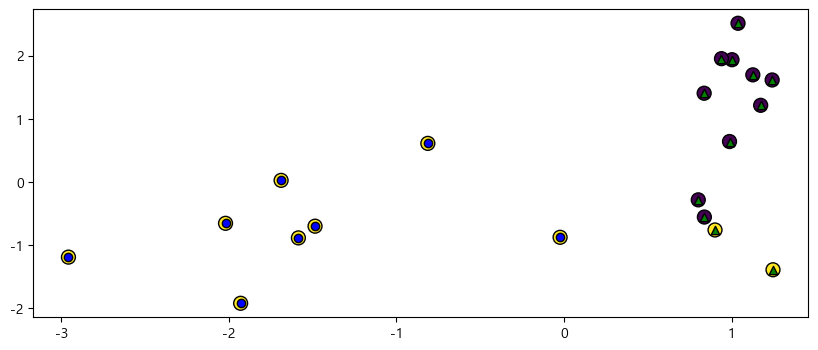

In [42]:

plt.scatter(X[:,0], X[:,1], c=y, s=100, edgecolors='k')
plt.scatter(X[labels==0,0],X[labels==0,1], marker='^', c='g', edgecolors='k')
plt.scatter(X[labels==1,0],X[labels==1,1], marker='o', c='b',edgecolors='k')


In [44]:
# x데이터를 Normalizer를 이용한 변환
import pandas as pd
from sklearn.preprocessing import Normalizer
scaler =Normalizer()
Xnor =scaler.fit_transform(X)
pd.DataFrame(X)
pd.concat([pd.DataFrame(X,columns=['x0','x1']),
         pd.DataFrame(Xnor, columns=['x0_nor','x1_nor'])]
         ,axis=1)


,x0,x1,x0_nor,x1_nor
0,1.038596,2.511754,0.382116,0.924114
1,1.002714,1.935215,0.460053,0.887892
2,-1.688105,0.025994,-0.999881,0.015397
3,0.901344,-0.758966,0.764937,-0.644105
4,0.836531,1.404882,0.511615,0.859215
5,-0.023176,-0.874812,-0.026484,-0.999649
6,0.837805,-0.554389,0.833951,-0.551839
7,-1.929572,-1.918940,-0.709057,-0.705151
8,-0.812496,0.611408,-0.799038,0.601281
9,1.126947,1.695701,0.553503,0.832847


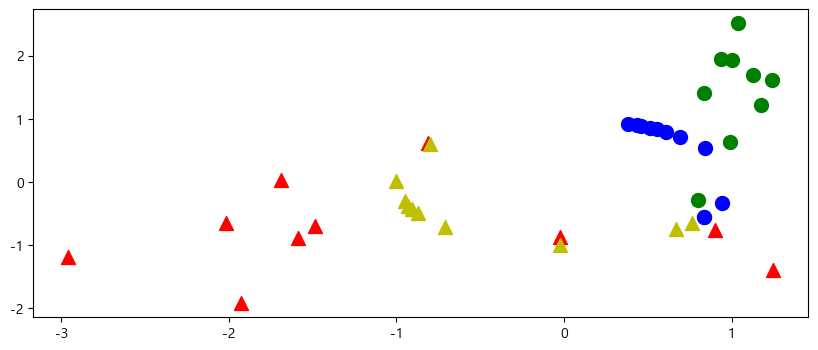

In [51]:
plt.scatter(X[y==0,0],X[y==0,1], s=100, marker='o', c='g')
plt.scatter(X[y==1,0],X[y==1,1], s=100, marker='^', c='r')

plt.scatter(Xnor[y==0,0],Xnor[y==0,1], s=100, marker='o', c='b')
plt.scatter(Xnor[y==1,0],Xnor[y==1,1], s=100, marker='^', c='y')

### K-means 클러스터링의 한계(pdf 13page)
- 군의 특성이 다를 경우
    - 크기(Sizes)
    - 밀도(Densities)
    - 비 구형(Non-globular shapes)
- 이상치를 포함할 경우 이상치를 없애고 클러스터링 진행

### 군의 크기가 다를경우


In [54]:
#np.random.normal(평균, 표준편차, size)
#group0 : 평균 -10 , 표준편차 2인 10행 2열 데이터 
group0 = np.random.normal(-10, 2, (10,2))
y0= np.full(group0.shape[0],0)
group0 = np.c_[group0,y0]
group0[:1]

array([[-10.87511794, -12.5638025 ,   0.        ]])

In [55]:
#group1 : 평균 10 , 표준편차 2인 10행 2열 데이터 
group1 = np.random.normal(10, 2, (10,2))
y1= np.full(group1.shape[0],1)
group1 = np.c_[group1,y1]
group1[:1]

array([[12.51895936, 13.36430394,  1.        ]])

In [56]:
#group1 : 평균 0 , 표준편차 5인 100행 2열 데이터 
group2 = np.random.normal(0, 5, (100,2))
y2= np.full(group2.shape[0],2)
group2 = np.c_[group2,y2]
group2[:1]

array([[0.95702901, 2.90673753, 2.        ]])

In [59]:
data = np.r_[group0, group1, group2]  # 120행 3열
data[::10]

array([[-10.87511794, -12.5638025 ,   0.        ],
       [ 12.51895936,  13.36430394,   1.        ],
       [  0.95702901,   2.90673753,   2.        ],
       [ -4.18319394,  -3.48050805,   2.        ],
       [ -9.87787865,   9.37915643,   2.        ],
       [ -1.932492  ,  -5.89154873,   2.        ],
       [  5.44616069,   2.00875261,   2.        ],
       [ -1.62151351,  -0.38509383,   2.        ],
       [  0.48222628,   1.50697122,   2.        ],
       [ 11.06810272,  -6.824508  ,   2.        ],
       [  2.41430086,   4.049302  ,   2.        ],
       [ -3.11172972,   5.83205851,   2.        ]])

In [60]:
group0.shape, group1.shape, group2.shape

((10, 3), (10, 3), (100, 3))

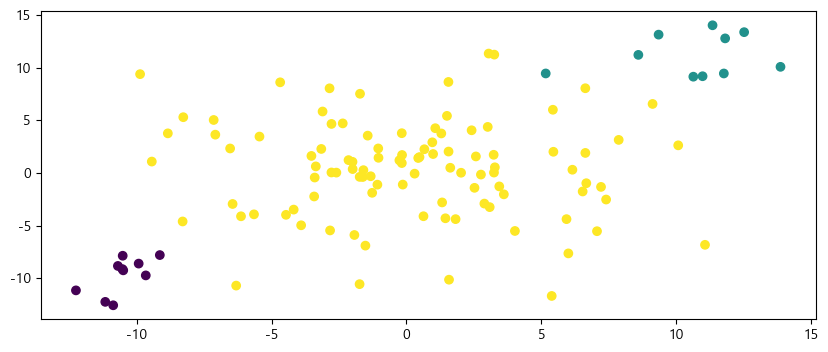

In [66]:
plt.scatter(data[:,0], data[:,1], c=data[:,2])

In [75]:
#3개그룹으로 클러스터링
model =KMeans(n_clusters=3,
             init ='k-means++',
             n_init=5)
model.fit(data[:,:2])

KMeans(n_clusters=3, n_init=5)

In [80]:
labels= model.labels_

In [82]:
centers =model.cluster_centers_ # 군의 중심점

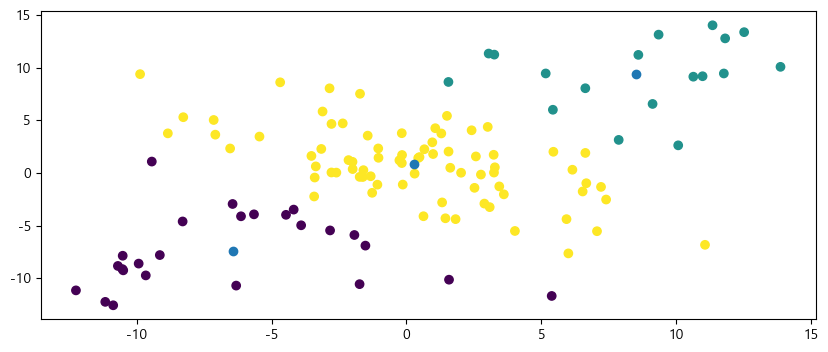

In [83]:
plt.scatter(data[:, 0], data[:, 1], c=labels)
plt.scatter(centers[:,0],centers[:,1], )

In [100]:
# 6개그룹으로 클러스터링
model =KMeans(n_clusters=6, init ='k-means++', n_init=5)
model.fit(data[:, :2])

KMeans(n_clusters=6, n_init=5)

In [101]:
centers=model.cluster_centers_ # 군의 중심점들

In [96]:
centers

array([[-9.99313192, -9.37117684],
       [-5.72813482,  5.23471536],
       [-2.95110955, -5.04227479],
       [-0.12375241,  1.58944078],
       [ 8.90124229, 10.3280685 ],
       [ 5.28431437, -2.52182402]])

In [102]:
labels=model.labels_
labels1=model.predict(data[:,:2])
labels == labels1

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True])

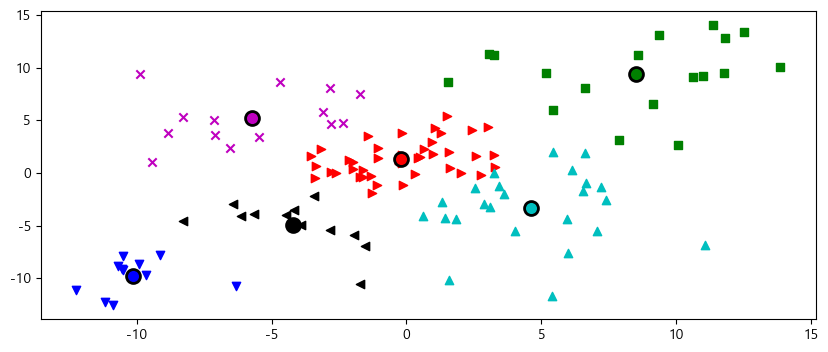

In [107]:
colors=['r','g','b','c','m','k']
markers=['>', 's', 'v', '^' ,  'x', '<']
for i, c in enumerate(centers):
    # print(i, c[0], c[1], data[labels==i][:2])
    plt.scatter(x= data[labels==i, 0],
               y= data[labels==i,1],
               c=colors[i],
               marker=markers[i])
    plt.scatter(c[0],c[1], s=100, c=colors[i], edgecolors='k', linewidths=2)
    
# 3 / 1 , 2 , 4 , 5 /0 

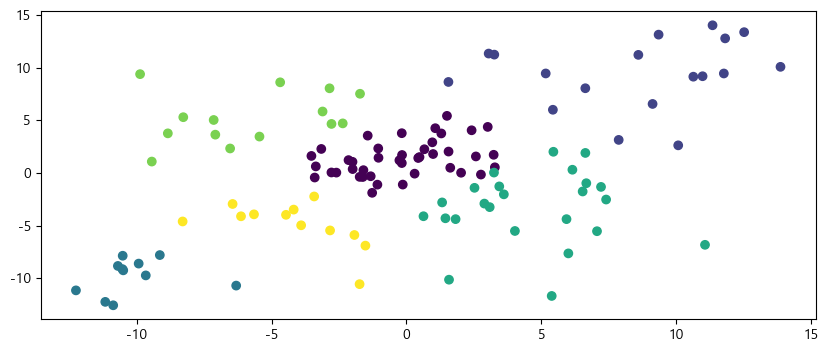

In [103]:
plt.scatter(data[:,0],data[:,1], c=labels)

# 3절. Hierachical 클러스터링(계층적 군집)
- 비슷한군끼리 묶으면서 하나의 군집이 될 때까지 군을 묶는 알고리즘
- 군집간의거리를 기반으로 클러스터링을 하는 알고리즘
- 군집의수를 미리 정해주지 않아도 됨
- dendrogram이라는 그래프를 이용하면 손쉽게 시각화

In [108]:
from seaborn import load_dataset
iris = load_dataset('iris')
iris.sample()

,sepal_length,sepal_width,petal_length,petal_width,species
29,4.7,3.2,1.6,0.2,setosa


In [110]:
# 계층적 군집화를 위해 모든 열들을 다숫자로 바꿔야함
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
iris['species']= le.fit_transform(iris['species'])
iris.iloc[::50]



,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,0
50,7.0,3.2,4.7,1.4,1
100,6.3,3.3,6.0,2.5,2


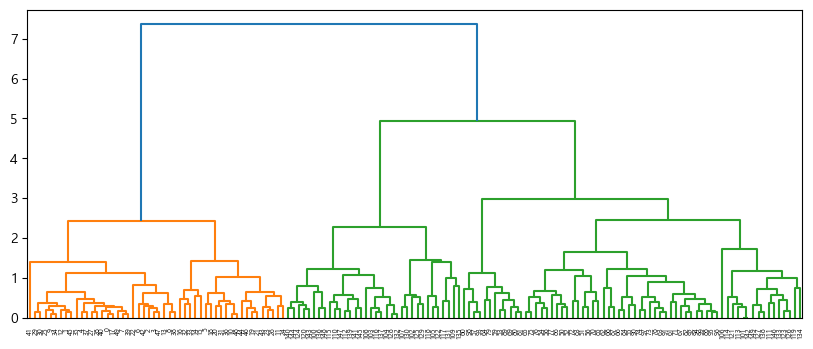

In [114]:
from scipy.cluster.hierarchy import linkage, dendrogram
# method : 각 클러스터간 거리를 어떻게 계산할지
cluster_model= linkage(iris, method='complete')   # 두 클러스터에서 가장 먼 거리를 이용해서 측정
dendrogram(cluster_model, labels=iris.index)
plt.savefig('data/ch2_dendrogram.png', dpi=300, bbox_inches='tight') # 파일저장
plt.show() # 화면 출력

In [118]:
# 클러스터 생성하는 함수 
from scipy.cluster.hierarchy import fcluster
fcluster(cluster_model, # linkage()로 만든 클러스터링 결과(모델)
        6, # 클러스터를 나누는 임계값
        criterion='distance')

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2], dtype=int32)

In [119]:
fcluster(cluster_model, # linkage()로 만든 클러스터링 결과(모델)
        4, # 클러스터를 나누는 임계값
        criterion='distance')

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 2, 3, 2, 2, 2, 2, 3, 2, 2, 2,
       2, 3, 2, 3, 3, 2, 2, 2, 2, 3, 2, 3, 2, 3, 2, 2, 3, 3, 2, 2, 2, 2,
       2, 3, 3, 2, 2, 2, 3, 2, 2, 2, 3, 2, 2, 2, 3, 2, 2, 3], dtype=int32)

In [124]:
fcluster(cluster_model, # linkage()로 만든 클러스터링 결과(모델)
        4, # 클러스터를 나누는 임계값
        criterion='distance')

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 2, 3, 2, 2, 2, 2, 3, 2, 2, 2,
       2, 3, 2, 3, 3, 2, 2, 2, 2, 3, 2, 3, 2, 3, 2, 2, 3, 3, 2, 2, 2, 2,
       2, 3, 3, 2, 2, 2, 3, 2, 2, 2, 3, 2, 2, 2, 3, 2, 2, 3], dtype=int32)

In [125]:
fcluster(cluster_model, # linkage()로 만든 클러스터링 결과(모델)
        3, # 클러스터의 갯수
        criterion='maxclust')

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 2, 3, 2, 2, 2, 2, 3, 2, 2, 2,
       2, 3, 2, 3, 3, 2, 2, 2, 2, 3, 2, 3, 2, 3, 2, 2, 3, 3, 2, 2, 2, 2,
       2, 3, 3, 2, 2, 2, 3, 2, 2, 2, 3, 2, 2, 2, 3, 2, 2, 3], dtype=int32)

In [127]:
pred=fcluster(cluster_model, # linkage()로 만든 클러스터링 결과(모델)
        4, # 클러스터의 갯수
        criterion='distance')
pred

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 2, 3, 2, 2, 2, 2, 3, 2, 2, 2,
       2, 3, 2, 3, 3, 2, 2, 2, 2, 3, 2, 3, 2, 3, 2, 2, 3, 3, 2, 2, 2, 2,
       2, 3, 3, 2, 2, 2, 3, 2, 2, 2, 3, 2, 2, 2, 3, 2, 2, 3], dtype=int32)

In [131]:
#위의 pred을 치환하는 문법

np.choose([3, 1, 2, 2],[0, 1, 2, 0])

array([0, 1, 2, 2])

In [132]:
adjusted_pred =np.choose(pred,[0,0,2,1])
adjusted_pred

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 2, 2, 2, 2, 1, 2, 2, 2,
       2, 1, 2, 1, 1, 2, 2, 2, 2, 1, 2, 1, 2, 1, 2, 2, 1, 1, 2, 2, 2, 2,
       2, 1, 1, 2, 2, 2, 1, 2, 2, 2, 1, 2, 2, 2, 1, 2, 2, 1])

In [136]:
pred_name= le.inverse_transform(adjusted_pred)
pred_name

array(['setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa',
       'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa',
       'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa',
       'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa',
       'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa',
       'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa',
       'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa',
       'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa',
       'setosa', 'setosa', 'versicolor', 'versicolor', 'versicolor',
       'versicolor', 'versicolor', 'versicolor', 'versicolor',
       'versicolor', 'versicolor', 'versicolor', 'versicolor',
       'versicolor', 'versicolor', 'versicolor', 'versicolor',
       'versicolor', 'versicolor', 'versicolor', 'versicolor',
       'versicolor', 'versicolor', 'versicolor', 'versicolor',
       'versicolor', 'versicolor', 'versicolor', 'versicolor',
       'versicolo

In [135]:
original_name=le.inverse_transform(iris['species'])
original_name

array(['setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa',
       'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa',
       'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa',
       'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa',
       'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa',
       'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa',
       'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa',
       'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa',
       'setosa', 'setosa', 'versicolor', 'versicolor', 'versicolor',
       'versicolor', 'versicolor', 'versicolor', 'versicolor',
       'versicolor', 'versicolor', 'versicolor', 'versicolor',
       'versicolor', 'versicolor', 'versicolor', 'versicolor',
       'versicolor', 'versicolor', 'versicolor', 'versicolor',
       'versicolor', 'versicolor', 'versicolor', 'versicolor',
       'versicolor', 'versicolor', 'versicolor', 'versicolor',
       'versicolo

In [137]:
pd.crosstab(original_name,pred_name,rownames=['실제값'], colnames=['예측값'],
           margins=True) # 행과 열의 총계 추가

예측값,setosa,versicolor,virginica,All
실제값,,,,
setosa,50,0,0,50
versicolor,0,50,0,50
virginica,0,16,34,50
All,50,66,34,150


<Axes: xlabel='petal_length', ylabel='petal_width'>

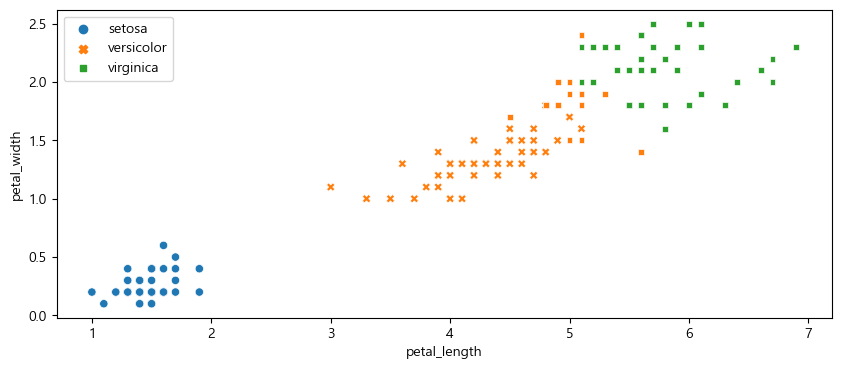

In [140]:
import seaborn as sns
sns.scatterplot(data=iris,
               x='petal_length',
               y='petal_width',
               hue=pred_name,
               style= original_name)

# 4절. DBSCAN 클러스터링
 - 연결기반(밀도기반) 군집화 알고리즘 (클러스터 수를 미리 정할 필요없음, 이상차를 자동감지)
 - 단점 : 클러스터의 밀도가 일정하지 않으면 성능 떨어짐
 - eps(반경)과 min_samples(최소샘플수)를 적헐히 조절하여 군집화
 

array([[ 1.27755956,  1.07396889,  0.        ],
       [ 2.88450858,  0.42818873,  0.        ],
       [ 2.77755956, -0.93259555,  1.        ],
       [ 4.38450858, -0.55854746,  1.        ]])

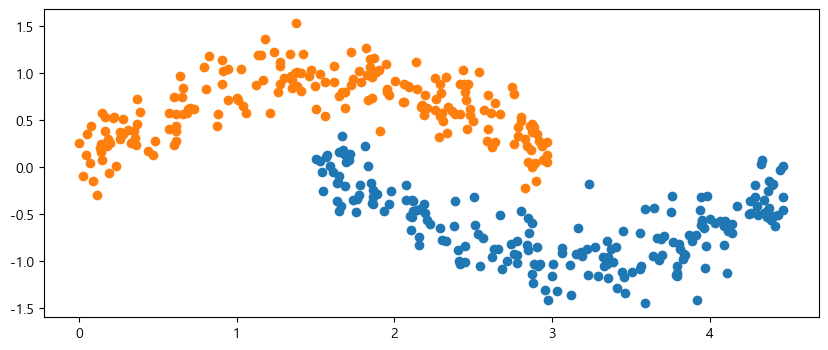

In [161]:
import numpy as np
X1=np.random.rand(200)*3 #rand(n) : 0<=x<1 의 균등포 난수 n개 발생
noise = np.random.normal(0,0.2,X1.shape)
Y1=np.sin(X1)+noise
group1 =np.c_[X1,Y1, np.zeros(X1.shape[0])]

X2= X1+1.5
noise = np.random.normal(0,0.205,X1.shape)
Y2=np.cos(X2)+noise
plt.scatter(X2,Y2)
plt.scatter(X1,Y1)
group2 =np.c_[X2,Y2, np.ones(X2.shape[0])]
data=np.r_[group1,group2]
data[::100]

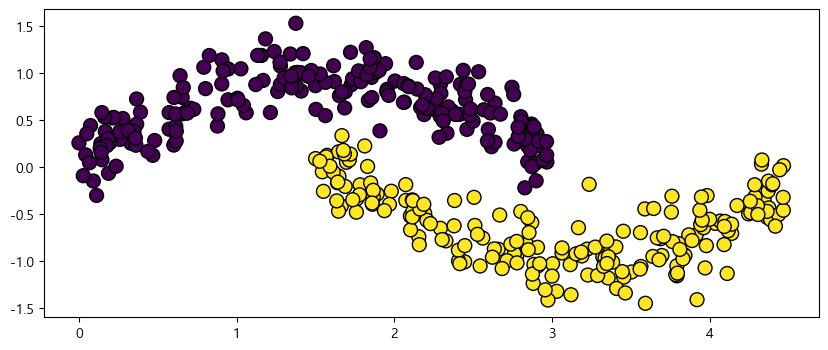

In [163]:
plt.scatter(data[:,0],data[:,1],c=data[:,2], s=100, edgecolors='k')

In [165]:
model = KMeans(n_clusters=2, n_init=5)
model.fit(data[:,:2])

KMeans(n_clusters=2, n_init=5)

In [172]:
labels=model.labels_ # 군집화 결과
centers = model.cluster_centers_ # 중심점

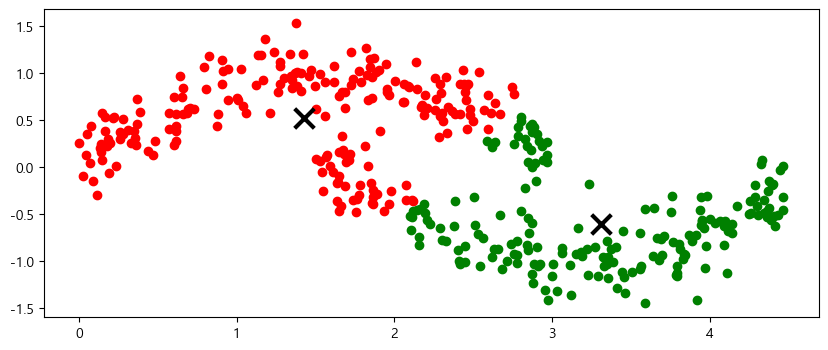

In [174]:
data[labels==1]
colors = ['r','g']
for i,c in enumerate(centers):
    plt.scatter(data[labels==i,0],
                data[labels==i,1], 
                c=colors[i])
    plt.scatter(c[0], c[1], c='k', marker='x', s=200, lw=3)

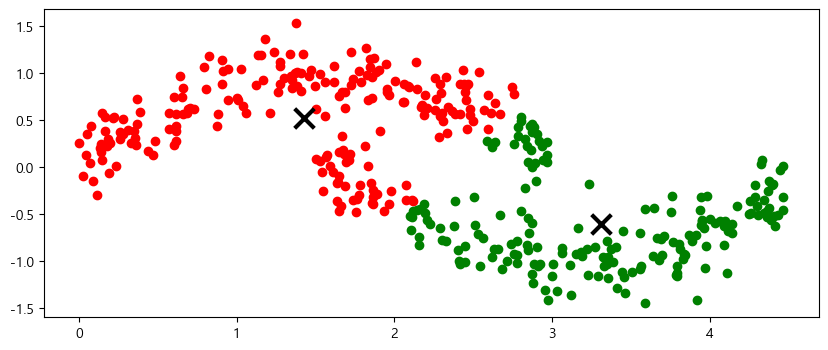

In [175]:
data[labels==1]
colors = ['r','g']
for i,c in enumerate(centers):
    plt.scatter(data[labels==i,0],
                data[labels==i,1], 
                c=colors[i])
    plt.scatter(c[0], c[1], c='k', marker='x', s=200, lw=3)

In [186]:
from sklearn.cluster import DBSCAN
db_model = DBSCAN(eps=0.27, min_samples=10) # 반경 0.3이내에 최소 10개가 있어야 군집
db_model.fit(data[:,:2])

DBSCAN(eps=0.27, min_samples=10)

In [189]:
labels=db_model.labels_
labels
n_clusters = len(set(labels))- (1 if -1 in labels else 0)

In [191]:
n_noise=list(labels).count(-1)

In [194]:
print(f'이상치를 제외한 label 갯수 :{n_clusters}, 이상치 갯수:{n_noise}')

이상치를 제외한 label 갯수 :2, 이상치 갯수:5


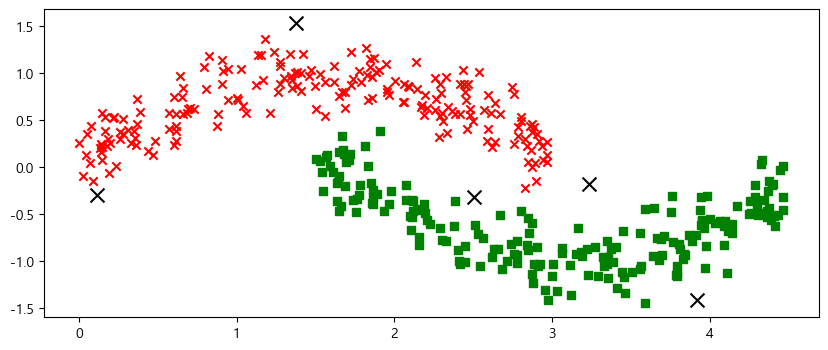

In [196]:
colors = ['r','g']
markers=['x','s']
for i in range(n_clusters):
    plt.scatter(data[labels==i,0],
                data[labels==i,1], 
                c=colors[i],marker=markers[i])
plt.scatter(data[labels==-1,0],data[labels==-1,1],c='k', marker='x', s=100)

# 5절. 군집모형 성능평가
- 예측 모형의 score(분류, 회귀)
    * score메소드를 통해서 예측 모형의 정확도(accuracy)를 평가
- metrics 패키지에 많은 함수 참조
    * 분류분석 recall, precision을 평가하는 함수
    * **군집 모형등의 평가를 위한 함수**
- scoring 매개변수
    * GridSearchCV클래스 -> 4장
    
    

In [197]:
from seaborn import load_dataset
iris = load_dataset('iris')
iris_X=iris.iloc[:,:-1]
iris_y=iris.iloc[:,-1]

In [198]:
from sklearn.cluster import KMeans
iris_3cluster_model = KMeans(n_clusters=3, random_state=1, n_init=10)
iris_3cluster_model.fit(iris_X)

KMeans(n_clusters=3, n_init=10, random_state=1)

In [199]:
pred3 = iris_3cluster_model.predict(iris_X)
pred3

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 2, 2, 2, 2, 0, 2, 2, 2,
       2, 2, 2, 0, 0, 2, 2, 2, 2, 0, 2, 0, 2, 0, 2, 2, 0, 0, 2, 2, 2, 2,
       2, 0, 2, 2, 2, 2, 0, 2, 2, 2, 0, 2, 2, 2, 0, 2, 2, 0])

In [202]:
pred3_str=np.choose(pred3, ['versicolor', 'setosa', 'virginica']) # 모델이 군집화한 데이터
# 군집분석의 성능평가 함수를 쓰기 위해서 pred3_str과 iris_y

array(['setosa', 'setosa', 'setosa'], dtype='<U10')

In [203]:
iris_y.value_counts()

setosa        50
versicolor    50
virginica     50
Name: species, dtype: int64

In [206]:
# iris_y를 라벨인코딩
from sklearn.preprocessing import LabelEncoder
le =LabelEncoder()
iris_y3=le.fit_transform(iris_y)
iris_y3
pred3= np.choose(pred3,[1,0,2])
# 군집분석의 성능 평가 함수를 쓰기 위해 pred3과 iris_y3(둘다 넘파이 배열)


In [211]:
iris_2cluster_model = KMeans(n_clusters=2, random_state=1, n_init=10)
iris_2cluster_model.fit(iris_X)

KMeans(n_clusters=2, n_init=10, random_state=1)

In [212]:
pred2 = iris_2cluster_model.predict(iris_X)
pred2

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

In [213]:
iris_y2=np.array([0]*50 + [1]*100)
# 군집분석의 성능 평가 함수를 쓰기 위해 pred2과 iris_y2(둘다 넘파이 배열)

In [218]:
pred2_str =np.choose(pred2,['setosa','그외'])
iris_y2_str=np.choose(iris_y2,['setosa','그외'])
# 군집분석의 성능 평가 함수를 쓰기 위해 pred2_str과 iris_y2_str(둘다 넘파이)

In [219]:
pd.crosstab(iris_y2_str,pred2_str)

col_0,setosa,그외
row_0,,
setosa,50,0
그외,3,97


In [221]:
pd.crosstab(iris_y,pred3_str)

col_0,setosa,versicolor,virginica
species,,,
setosa,50,0,0
versicolor,0,48,2
virginica,0,14,36


In [224]:
pred3_str.shape,iris_y.shape, pred3.shape, iris_y3.shape

((150,), (150,), (150,), (150,))

In [225]:
pred2.shape,iris_y2.shape, pred2_str.shape, iris_y2_str.shape

((150,), (150,), (150,), (150,))

## 5.1 조정된 rand 지수 
- 조정된 랜드지수는 두 클러스터링(pred,iris_y값이)이 얼마나 같은 쌍을 만들어내는지

In [226]:
# 클러스터갯수가 3개인 경우 성능평가
from sklearn.metrics import adjusted_rand_score
adjusted_rand_score(labels_true = iris_y,
                    labels_pred= pred3_str)

0.7302382722834697

In [227]:
adjusted_rand_score(labels_true= iris_y3,
                   labels_pred= pred3)

0.7302382722834697

In [228]:
# 클러스터갯수가 2개인 경우 성능 평가
adjusted_rand_score(labels_true= iris_y2,
                   labels_pred=pred2)

0.920405050901892

In [229]:
adjusted_rand_score(labels_true= iris_y2_str,
                   labels_pred=pred2_str)

0.920405050901892

## 5.2 상호 의존도를 나타내는 지표
mutual_info_score
normalized_mutual_info_score

In [230]:
from sklearn.metrics import mutual_info_score
# 클러스터가 3인경우
print(mutual_info_score(iris_y, pred3_str))
print(mutual_info_score(iris_y3, pred3))

0.8255910976103356
0.8255910976103356


In [231]:
# 클러스터가 2인경우
print(mutual_info_score(iris_y2, pred2))
print(mutual_info_score(iris_y2_str, pred2_str))

0.5596576064224734
0.5596576064224734


In [233]:
from sklearn.metrics import normalized_mutual_info_score
print(normalized_mutual_info_score(iris_y, pred3_str))
print(normalized_mutual_info_score(iris_y3, pred3))

0.7581756800057784
0.7581756800057784


In [234]:
print(normalized_mutual_info_score(iris_y2, pred2))
print(normalized_mutual_info_score(iris_y2_str, pred2_str))

0.8703851565631638
0.8703851565631638


In [235]:
from sklearn.metrics import homogeneity_score
# 클러스터가 3인경우
print(homogeneity_score(iris_y, pred3_str))
print(homogeneity_score(iris_y3, pred3))

0.7514854021988338
0.7514854021988338


In [236]:
# 클러스터가 2인경우
print(homogeneity_score(iris_y2, pred2))
print(homogeneity_score(iris_y2_str, pred2_str))

0.8792539652679946
0.8792539652679946


In [238]:
from sklearn.metrics import completeness_score
print(completeness_score(iris_y3, pred3)) # 클러스터 3개
print(completeness_score(iris_y2, pred2)) # 클러스터 2개

0.7649861514489815
0.861693475999054


In [239]:
from sklearn.metrics import v_measure_score
print(v_measure_score(iris_y3, pred3)) # 클러스터 3개
print(v_measure_score(iris_y2, pred2)) # 클러스터 2개

0.7581756800057784
0.870385156563164


## 5.3 실루엣 계수

array([[ 1.09495118,  0.70059416,  0.        ],
       [ 0.96635445,  0.85287884,  0.        ],
       [ 2.59495118, -0.6236385 ,  1.        ],
       [ 2.46635445, -1.14647353,  1.        ]])

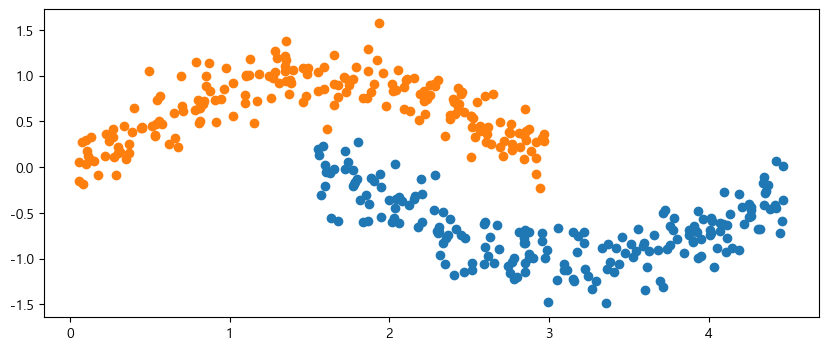

In [12]:
import numpy as np
X1=np.random.rand(200)*3 #rand(n) : 0<=x<1 의 균등포 난수 n개 발생
noise = np.random.normal(0,0.2,X1.shape)
Y1=np.sin(X1)+noise
group1 =np.c_[X1,Y1, np.zeros(X1.shape[0])]

X2= X1+1.5
noise = np.random.normal(0,0.205,X1.shape)
Y2=np.cos(X2)+noise
plt.scatter(X2,Y2)
plt.scatter(X1,Y1)
group2 =np.c_[X2,Y2, np.ones(X2.shape[0])]
data=np.r_[group1,group2]
data[::100]

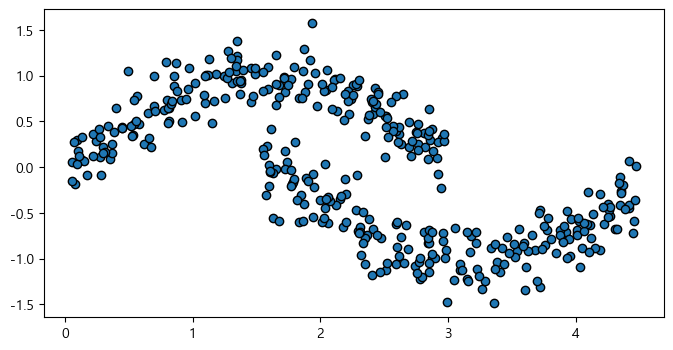

In [22]:
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings(action='ignore')
plt.rc('font',family='Malgun Gothic')
plt.rcParams['font.family']='Malgun Gothic'  #한글 꺠짐 방지
plt.rcParams['axes.unicode_minus'] =False    # 축의 깨짐방지
plt.rcParams['figure.figsize'] = (8,4) # 모든 시각화 사이즈
plt.scatter(x=data[:,0],y=data[:,1], edgecolors='k')
plt.show()

In [34]:
# 실루엣 계수 구하기
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans
range_n_clusters = [2, 3, 4, 5, 6 , 7, 8, 9, 10, 11, 12]
for n_clusters in range_n_clusters:
    #print(n_clusters)
    model = KMeans(n_clusters=n_clusters, n_init=10, random_state=3)
    model.fit(data[:,:-1])
    cluster_labels=model.labels_
    #print(cluster_labels[:5])
    # cluster_labels의 성능지표 : 실루엣 계수
    score=silhouette_score(data[:,:-1],   #학습데이터
                          cluster_labels) #결과 클러스터 레이블
    print(f'클러스터수 : {n_clusters}일 때, 실루엣 계수는 {score}')

클러스터수 : 2일 때, 실루엣 계수는 0.5031777177106276
클러스터수 : 3일 때, 실루엣 계수는 0.46978565845053516
클러스터수 : 4일 때, 실루엣 계수는 0.4709088802734318
클러스터수 : 5일 때, 실루엣 계수는 0.4563391705453346
클러스터수 : 6일 때, 실루엣 계수는 0.5132250425993949
클러스터수 : 7일 때, 실루엣 계수는 0.4956678271043463
클러스터수 : 8일 때, 실루엣 계수는 0.4756043985999234
클러스터수 : 9일 때, 실루엣 계수는 0.47223803998548175
클러스터수 : 10일 때, 실루엣 계수는 0.45818225780108224
클러스터수 : 11일 때, 실루엣 계수는 0.44783634110913356
클러스터수 : 12일 때, 실루엣 계수는 0.4388557852196855


# 6절. 연습문제 
iris 데이터의 petal_length열과 petal_width열을 이용해서 K-Means 알고리즘으로 군집화하였을때,
최적의 클러스터수를 실로엣 계수를 이용하여 분석하세요
분석한 결과로 시각화 하세요
(단, 각 클러스터의 중심점이 함께 표시되고 군의 수는 2와 3으로 설정하여 시각화하고 실루엣 계수를 비교)

In [39]:
from seaborn import load_dataset
iris=load_dataset('iris')
iris.sample()

,sepal_length,sepal_width,petal_length,petal_width,species
136,6.3,3.4,5.6,2.4,virginica


In [46]:
data= iris.iloc[:,2:4]
data

,petal_length,petal_width
0,1.4,0.2
1,1.4,0.2
2,1.3,0.2
3,1.5,0.2
4,1.4,0.2
...,...,...
145,5.2,2.3
146,5.0,1.9
147,5.2,2.0
148,5.4,2.3


array([[1.49215686, 0.2627451 ],
       [4.92525253, 1.68181818]])

0.7653904101258123


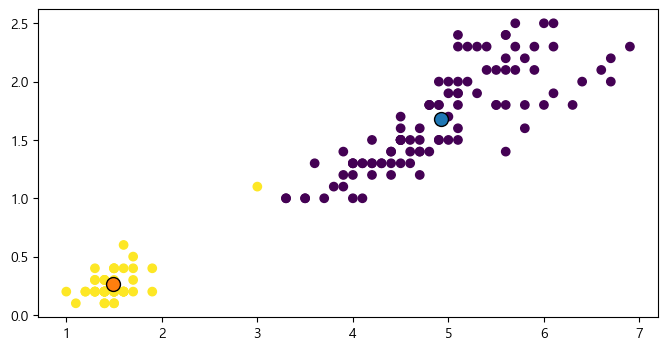

In [73]:
model = KMeans(n_clusters=2, n_init=10)
model.fit(data)
cluster_labels=model.labels_
c0, c1=model.cluster_centers_
score2=silhouette_score(data, cluster_labels)
print(score2)
plt.scatter(x=data.iloc[:,0],y=data.iloc[:,1], c=cluster_labels)
plt.scatter(c0[0],c0[1], s=100, edgecolors='k')
plt.scatter(c1[0],c1[1], s=100, edgecolors='k')

0.6604800083974887


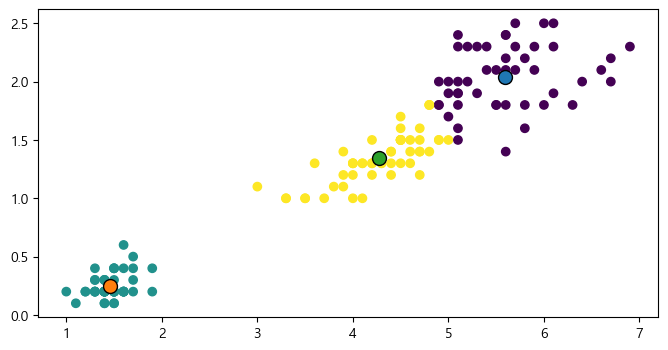

In [74]:
model = KMeans(n_clusters=3, n_init=10)
model.fit(data)
cluster_labels=model.labels_
c0, c1, c2=model.cluster_centers_
score3=silhouette_score(data, cluster_labels)
print(score3)
plt.scatter(x=data.iloc[:,0],y=data.iloc[:,1], c=cluster_labels)
plt.scatter(c0[0],c0[1], s=100, edgecolors='k')
plt.scatter(c1[0],c1[1], s=100, edgecolors='k')
plt.scatter(c2[0],c2[1], s=100, edgecolors='k')

In [77]:
print(f'cluster2개일때 실루엣계수:{score2},\n  cluster3개일때 실루엣계수:{score3}')

cluster2개일때 실루엣계수:0.7653904101258123,
  cluster3개일때 실루엣계수:0.6604800083974887
